In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges dtype now:", df['TotalCharges'].dtype)
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

TotalCharges dtype now: float64
Missing values in TotalCharges: 11


In [10]:
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)
# Should be (7032, 21)

Shape after cleaning: (7032, 21)


In [11]:
df.drop('customerID', axis=1, inplace=True)
print("Columns now:", df.shape)

Columns now: (7032, 20)


In [13]:
print(df['Churn'].value_counts())
print("\nPercentage:")
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


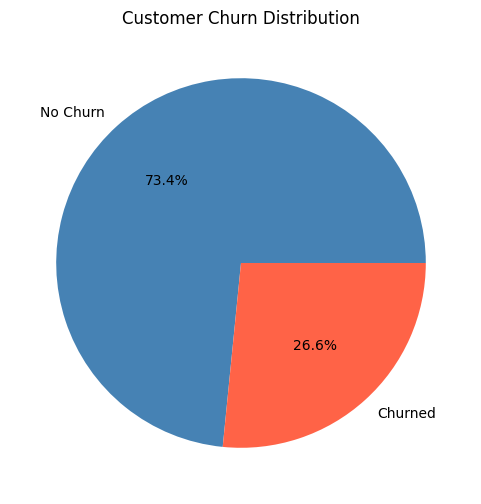

In [14]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 colors=['steelblue','tomato'],
                                 labels=['No Churn','Churned'])
plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

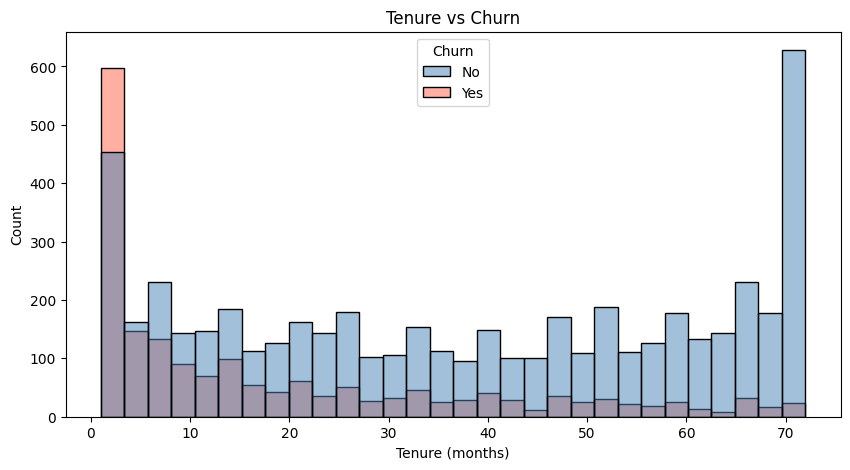

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue','tomato'])
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.show()

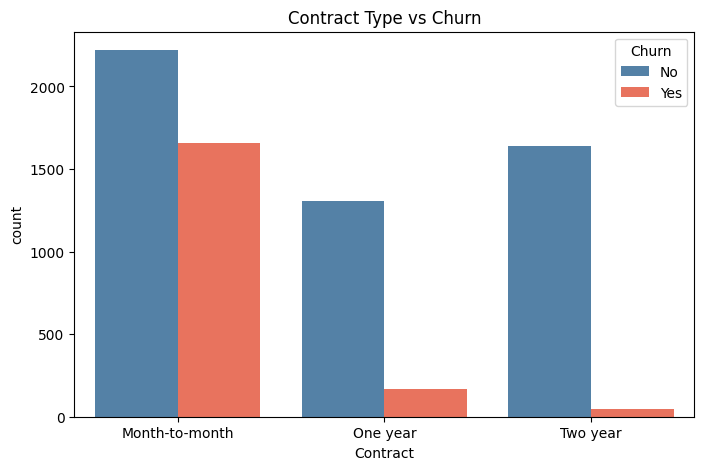

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue','tomato'])
plt.title('Contract Type vs Churn')
plt.show()

/tmp/ipykernel_4435/3951971828.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['steelblue','tomato'])


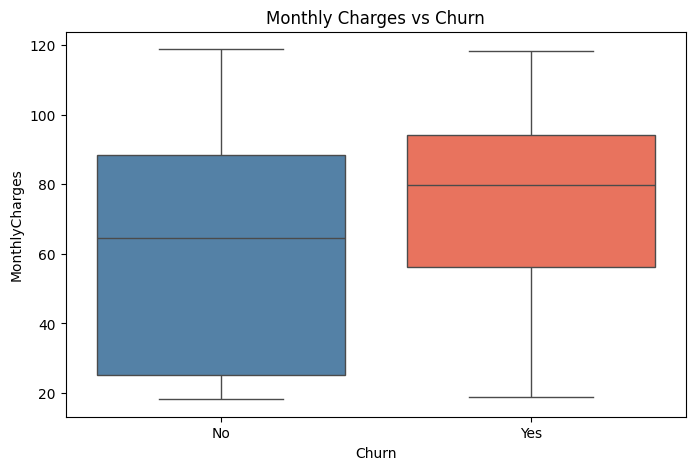

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['steelblue','tomato'])
plt.title('Monthly Charges vs Churn')
plt.show()

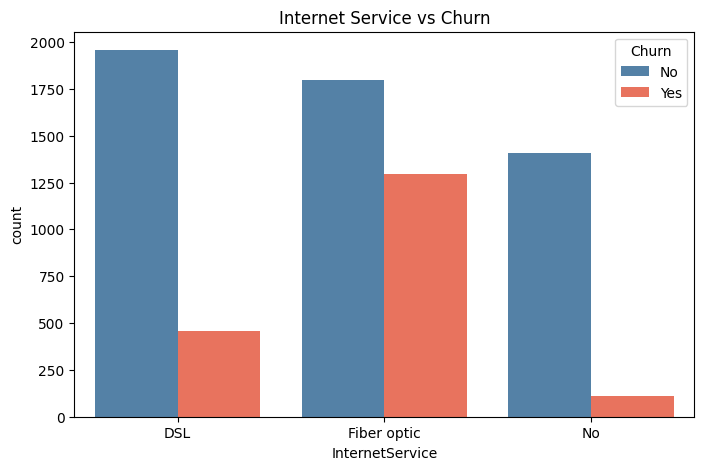

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['steelblue','tomato'])
plt.title('Internet Service vs Churn')
plt.show()

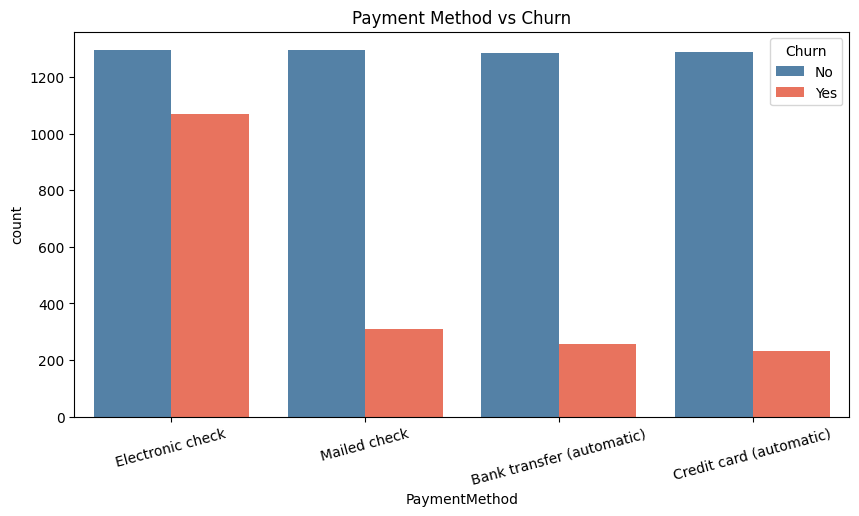

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['steelblue','tomato'])
plt.xticks(rotation=15)
plt.title('Payment Method vs Churn')
plt.show()

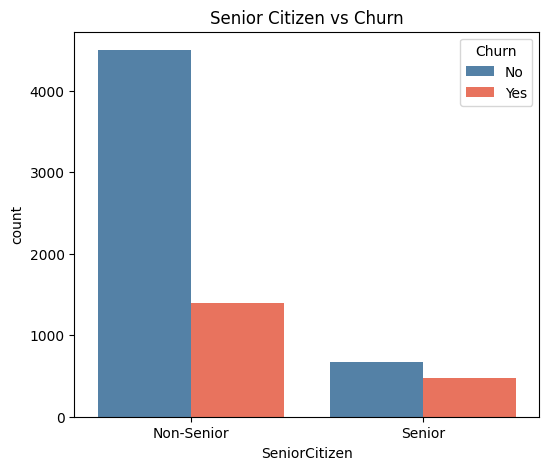

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette=['steelblue','tomato'])
plt.title('Senior Citizen vs Churn')
plt.xticks([0,1], ['Non-Senior','Senior'])
plt.show()

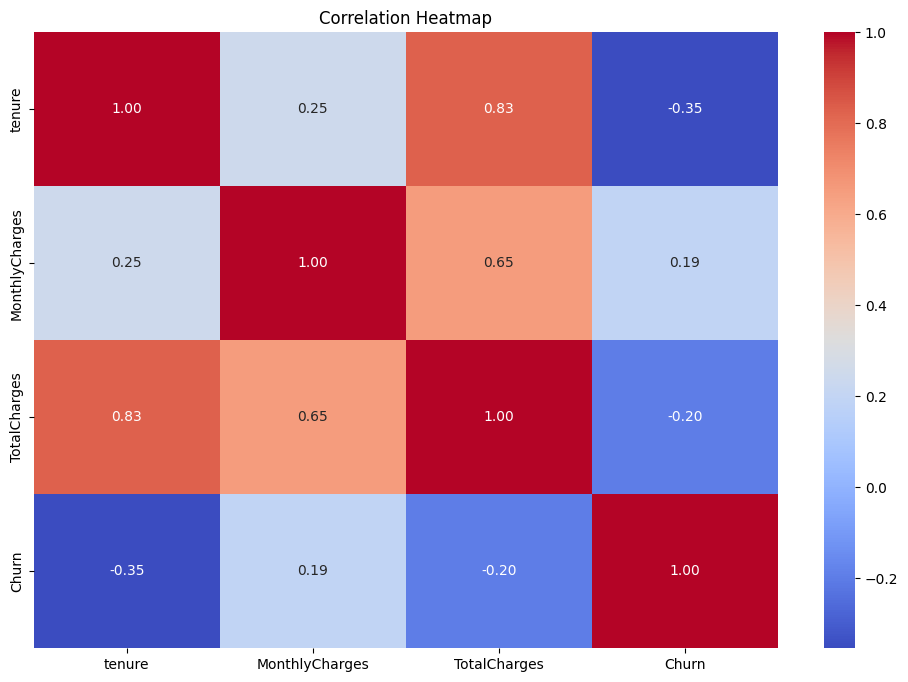

In [21]:
plt.figure(figsize=(12,8))
numerical_df = df[['tenure','MonthlyCharges','TotalCharges']].copy()
numerical_df['Churn'] = (df['Churn'] == 'Yes').astype(int)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
binary_cols = ['gender','Partner','Dependents','PhoneService',
               'PaperlessBilling','Churn']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Done! ✅")
print(df[binary_cols].head())

Done! ✅
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


In [23]:
multi_cols = ['MultipleLines','InternetService','OnlineSecurity',
              'OnlineBackup','DeviceProtection','TechSupport',
              'StreamingTV','StreamingMovies','Contract','PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Done! ✅")

Shape after encoding: (7032, 31)
Done! ✅


In [24]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nChurn value counts:\n", y.value_counts())

X shape: (7032, 30)
y shape: (7032,)

Churn value counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)
print("Done! ✅")

Training set size: (5625, 30)
Testing set size:  (1407, 30)
Done! ✅


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done! ✅")

Scaling done! ✅


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC Score: 0.8357


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8142


In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]), 4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

ROC-AUC Score: 0.8196


In [30]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 4),
        round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 4),
        round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]), 4)
    ]
})

print(results.sort_values('ROC-AUC', ascending=False))

                 Model  ROC-AUC
0  Logistic Regression   0.8357
2              XGBoost   0.8196
1        Random Forest   0.8142


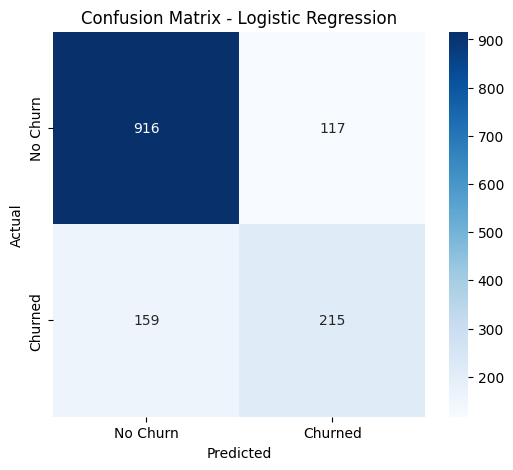

In [31]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churned'],
            yticklabels=['No Churn','Churned'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

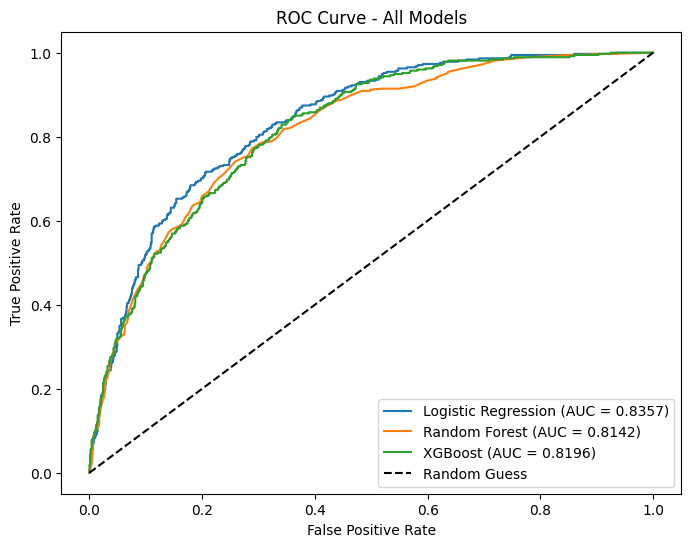

In [32]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in [('Logistic Regression', lr),
                     ('Random Forest', rf),
                     ('XGBoost', xgb)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()

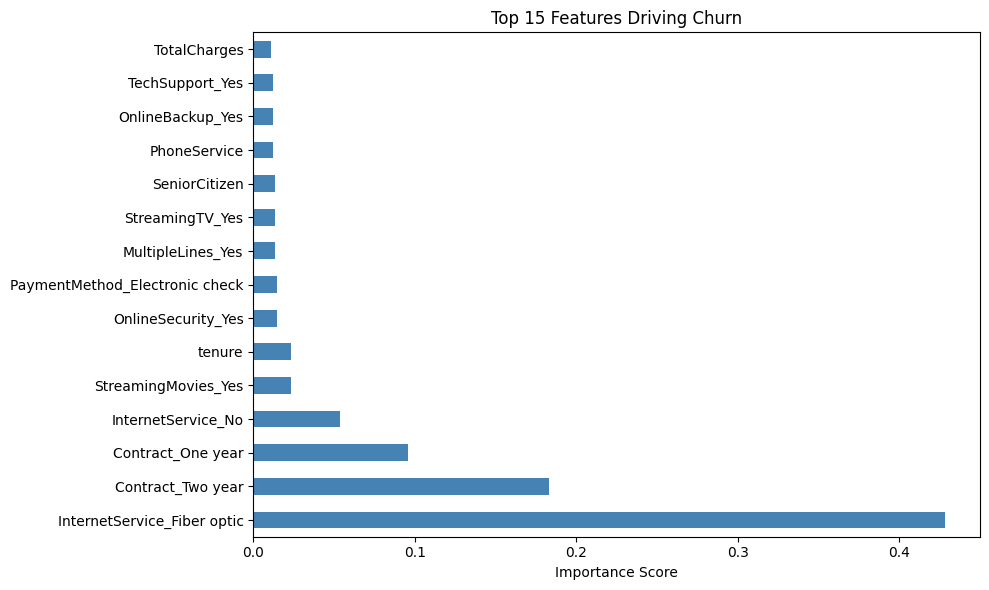

In [33]:
feat_imp = pd.Series(xgb.feature_importances_,
                     index=df.drop('Churn', axis=1).columns)

plt.figure(figsize=(10,6))
feat_imp.nlargest(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Driving Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [34]:
contract_churn = df.groupby('Contract_Two year')['Churn'].mean() * 100
print("Churn Analysis by Key Features:")
print("\nAvg Monthly Charges - Churned vs Not:")
print(round(df.groupby('Churn')['MonthlyCharges'].mean(), 2))
print("\nAvg Tenure - Churned vs Not:")
print(round(df.groupby('Churn')['tenure'].mean(), 2))
print("\nAvg TotalCharges - Churned vs Not:")
print(round(df.groupby('Churn')['TotalCharges'].mean(), 2))

Churn Analysis by Key Features:

Avg Monthly Charges - Churned vs Not:
Churn
0    61.31
1    74.44
Name: MonthlyCharges, dtype: float64

Avg Tenure - Churned vs Not:
Churn
0    37.65
1    17.98
Name: tenure, dtype: float64

Avg TotalCharges - Churned vs Not:
Churn
0    2555.34
1    1531.80
Name: TotalCharges, dtype: float64


In [35]:
print("Churn Rate by Senior Citizen:")
print(round(df.groupby('SeniorCitizen')['Churn'].mean() * 100, 2))

print("\nChurn Rate by Gender:")
print(round(df.groupby('gender')['Churn'].mean() * 100, 2))

print("\nChurn Rate by Partner:")
print(round(df.groupby('Partner')['Churn'].mean() * 100, 2))

print("\nChurn Rate by Dependents:")
print(round(df.groupby('Dependents')['Churn'].mean() * 100, 2))

Churn Rate by Senior Citizen:
SeniorCitizen
0    23.65
1    41.68
Name: Churn, dtype: float64

Churn Rate by Gender:
gender
0    26.96
1    26.20
Name: Churn, dtype: float64

Churn Rate by Partner:
Partner
0    32.98
1    19.72
Name: Churn, dtype: float64

Churn Rate by Dependents:
Dependents
0    31.28
1    15.53
Name: Churn, dtype: float64


In [36]:
# Create a sample customer profile
import warnings
warnings.filterwarnings('ignore')

sample = X_test[0].reshape(1, -1)
prob = lr.predict_proba(sample)[0][1]
print(f"Churn Probability for this customer: {round(prob*100, 2)}%")

if prob > 0.5:
    print("⚠️ HIGH RISK — This customer is likely to churn!")
else:
    print("✅ LOW RISK — This customer is likely to stay!")

Churn Probability for this customer: 1.71%
✅ LOW RISK — This customer is likely to stay!


In [37]:
print("""
╔══════════════════════════════════════════════════╗
║         PROJECT SUMMARY - CHURN ANALYSIS         ║
╠══════════════════════════════════════════════════╣
║  Total Customers Analyzed  : 7032                ║
║  Churn Rate                : 26.58%              ║
║  Best Model                : Logistic Regression ║
║  Best ROC-AUC Score        : 0.8357              ║
╠══════════════════════════════════════════════════╣
║  KEY BUSINESS INSIGHTS:                          ║
║  1. Short tenure customers churn the most        ║
║  2. Month-to-month contracts = highest churn     ║
║  3. Higher monthly charges = more churn          ║
║  4. Senior citizens churn more                   ║
║  5. Customers without partners churn more        ║
╠══════════════════════════════════════════════════╣
║  RECOMMENDATIONS:                                ║
║  1. Offer discounts to new customers             ║
║  2. Promote annual/2-year contracts              ║
║  3. Review pricing for high-charge customers     ║
║  4. Special retention plan for senior citizens   ║
║  5. Target single customers with offers          ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║         PROJECT SUMMARY - CHURN ANALYSIS         ║
╠══════════════════════════════════════════════════╣
║  Total Customers Analyzed  : 7032                ║
║  Churn Rate                : 26.58%              ║
║  Best Model                : Logistic Regression ║
║  Best ROC-AUC Score        : 0.8357              ║
╠══════════════════════════════════════════════════╣
║  KEY BUSINESS INSIGHTS:                          ║
║  1. Short tenure customers churn the most        ║
║  2. Month-to-month contracts = highest churn     ║
║  3. Higher monthly charges = more churn          ║
║  4. Senior citizens churn more                   ║
║  5. Customers without partners churn more        ║
╠══════════════════════════════════════════════════╣
║  RECOMMENDATIONS:                                ║
║  1. Offer discounts to new customers             ║
║  2. Promote annual/2-year contracts              ║
║  3. Review pricing for high-charge customer

In [38]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {0: 4130, 1: 4130}


In [39]:
# Retrain all 3 models
lr_sm = LogisticRegression(max_iter=1000)
lr_sm.fit(X_train_sm, y_train_sm)

rf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)

xgb_sm = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_sm.fit(X_train_sm, y_train_sm)

print("All models retrained with SMOTE! ✅")

All models retrained with SMOTE! ✅


In [40]:
print("=== ROC-AUC COMPARISON ===\n")
models_compare = {
    'Logistic Regression': (lr, lr_sm),
    'Random Forest':       (rf, rf_sm),
    'XGBoost':             (xgb, xgb_sm)
}

for name, (original, smote_model) in models_compare.items():
    orig_auc  = roc_auc_score(y_test, original.predict_proba(X_test)[:,1])
    smote_auc = roc_auc_score(y_test, smote_model.predict_proba(X_test)[:,1])
    print(f"{name}")
    print(f"  Before SMOTE: {orig_auc:.4f}")
    print(f"  After SMOTE:  {smote_auc:.4f}")
    print()

=== ROC-AUC COMPARISON ===

Logistic Regression
  Before SMOTE: 0.8357
  After SMOTE:  0.8339

Random Forest
  Before SMOTE: 0.8142
  After SMOTE:  0.8151

XGBoost
  Before SMOTE: 0.8196
  After SMOTE:  0.8164



In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_tune = XGBClassifier(eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    xgb_tune, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)
print("\nBest Parameters:", grid_search.best_params_)
print("Best ROC-AUC:   ", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC:    0.9365


In [42]:
best_xgb = grid_search.best_estimator_
best_preds = best_xgb.predict(X_test)
best_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])

print("=== Tuned XGBoost Results ===")
print(classification_report(y_test, best_preds))
print(f"ROC-AUC Score: {best_auc:.4f}")

=== Tuned XGBoost Results ===
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.59      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

ROC-AUC Score: 0.8168


In [43]:
orig_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
tuned_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])

print("=== XGBoost Improvement ===")
print(f"Original XGBoost ROC-AUC : {orig_auc:.4f}")
print(f"Tuned XGBoost ROC-AUC    : {tuned_auc:.4f}")
print(f"Improvement              : +{round(tuned_auc - orig_auc, 4)}")

=== XGBoost Improvement ===
Original XGBoost ROC-AUC : 0.8196
Tuned XGBoost ROC-AUC    : 0.8168
Improvement              : +-0.0028


In [44]:
!pip install shap -q
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)
print("SHAP values computed! ✅")

SHAP values computed! ✅


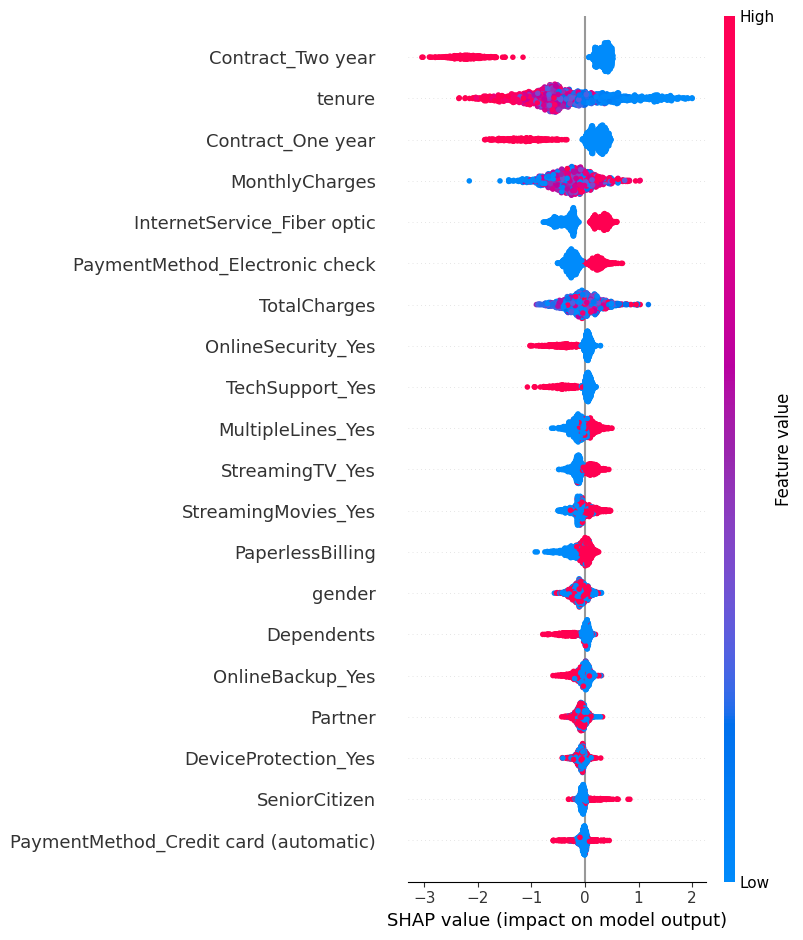

In [45]:
feature_names = df.drop('Churn', axis=1).columns.tolist()

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names)

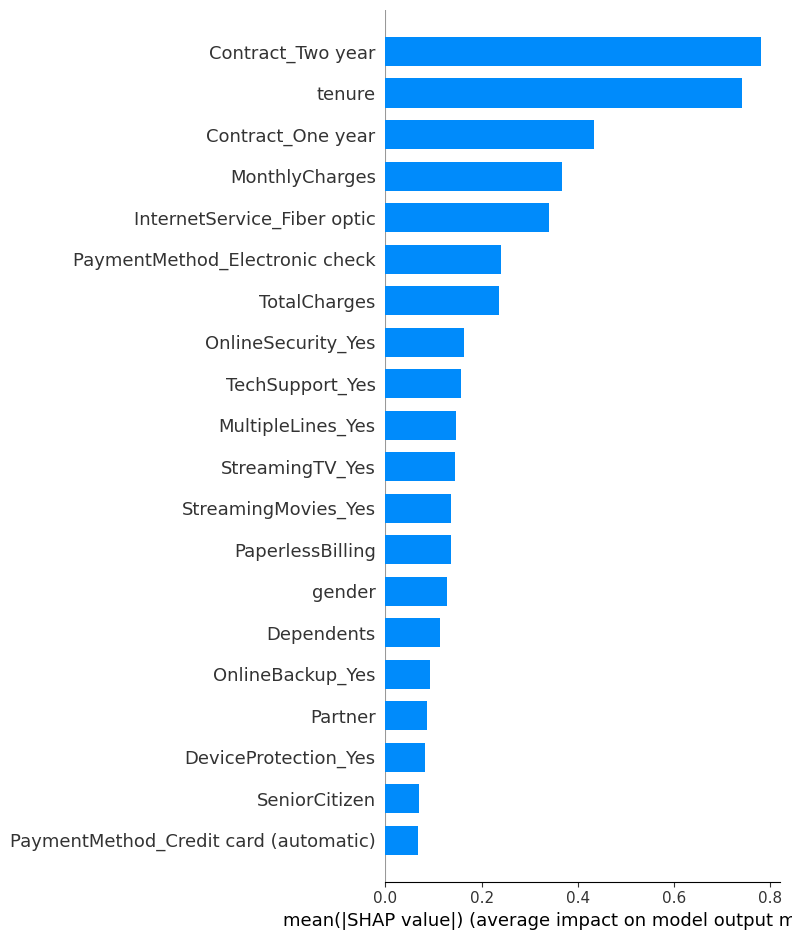

In [46]:
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  plot_type='bar')

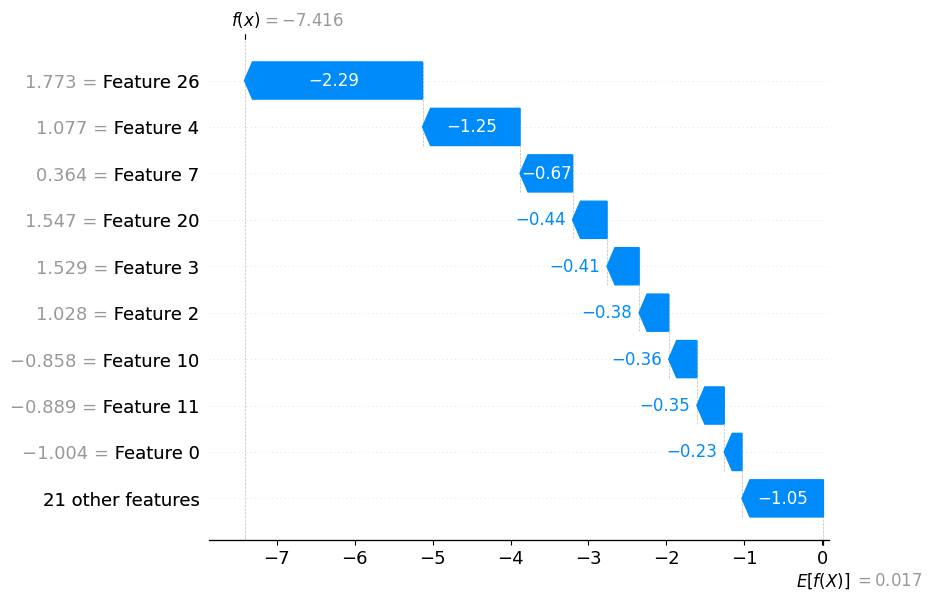

In [47]:
# Explain why customer 0 was predicted to churn or not
shap.waterfall_plot(shap_values[0])